
Aim: To implement the K-means clustering algorithm and analyze the clustering using appropriate evaluation techniques.extra:09 prac
Name : Vaishnavi G Sandokar



In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
path="/content/WineQT.csv"
df=pd.read_csv(path)
df.head(5)

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,Id
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5,0
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5,1
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5,2
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6,3
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5,4


In [ ]:
df.shape

(1143, 13)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1143 entries, 0 to 1142
Data columns (total 13 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed acidity         1143 non-null   float64
 1   volatile acidity      1143 non-null   float64
 2   citric acid           1143 non-null   float64
 3   residual sugar        1143 non-null   float64
 4   chlorides             1143 non-null   float64
 5   free sulfur dioxide   1143 non-null   float64
 6   total sulfur dioxide  1143 non-null   float64
 7   density               1143 non-null   float64
 8   pH                    1143 non-null   float64
 9   sulphates             1143 non-null   float64
 10  alcohol               1143 non-null   float64
 11  quality               1143 non-null   int64  
 12  Id                    1143 non-null   int64  
dtypes: float64(11), int64(2)
memory usage: 116.2 KB


In [ ]:
X=df.iloc[:,[3,4]].values

In [ ]:
X

array([[1.9  , 0.076],
       [2.6  , 0.098],
       [2.3  , 0.092],
       ...,
       [2.   , 0.09 ],
       [2.2  , 0.062],
       [2.   , 0.075]])

In [ ]:
scaler=StandardScaler()
X_scaled=scaler.fit_transform(X)

In [ ]:
print(X_scaled)

[[-0.46642142 -0.23139486]
 [ 0.05006018  0.23424656]
 [-0.17128908  0.10725344]
 ...
 [-0.39263833  0.06492241]
 [-0.24507216 -0.52771212]
 [-0.39263833 -0.25256038]]


In [ ]:
inertia_values=[]
for k in range(1,8):
  kmeans = KMeans(n_clusters=k,random_state=42)
  kmeans.fit(X_scaled)
  inertia_values.append(kmeans.inertia_)
print(inertia_values)


[2286.000000000005, 1501.3598860914428, 761.3961622476105, 633.4432682350536, 505.9773376469779, 364.2213841246995, 287.7285247528405]


[2286.000000000005, 1501.3598860914428, 761.3961622476105, 633.4432682350536, 505.9773376469779, 364.2213841246995, 287.7285247528405]


<function matplotlib.pyplot.show(close=None, block=None)>

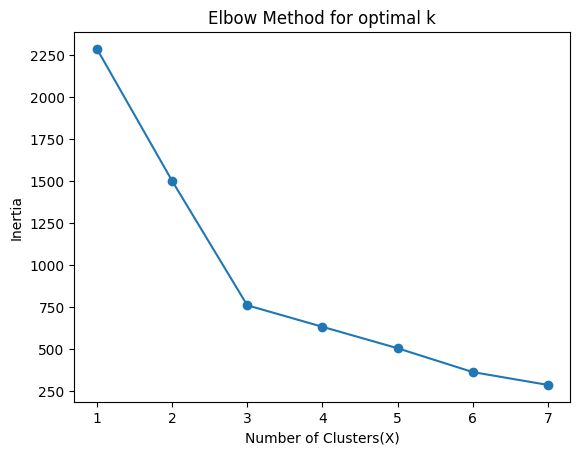

In [ ]:
print(inertia_values)
plt.figure()
plt.plot(range(1,8),inertia_values,marker='o')
plt.xlabel('Number of Clusters(X)')
plt.ylabel('Inertia')
plt.title('Elbow Method for optimal k')
plt.show


In [ ]:
kmeans = KMeans(n_clusters=3,random_state=42)
clusters = kmeans.fit_predict(X_scaled)
df['cluster']=clusters
print(df.head)

<bound method NDFrame.head of       fixed acidity  volatile acidity  citric acid  residual sugar  chlorides  \
0               7.4             0.700         0.00             1.9      0.076   
1               7.8             0.880         0.00             2.6      0.098   
2               7.8             0.760         0.04             2.3      0.092   
3              11.2             0.280         0.56             1.9      0.075   
4               7.4             0.700         0.00             1.9      0.076   
...             ...               ...          ...             ...        ...   
1138            6.3             0.510         0.13             2.3      0.076   
1139            6.8             0.620         0.08             1.9      0.068   
1140            6.2             0.600         0.08             2.0      0.090   
1141            5.9             0.550         0.10             2.2      0.062   
1142            5.9             0.645         0.12             2.0      0.075  

In [ ]:
print('inertia:',kmeans.inertia_)
sil_score=silhouette_score(X_scaled,clusters)
print('Silhouette Score:',sil_score)

inertia: 761.3961622476105
Silhouette Score: 0.7507560503938105


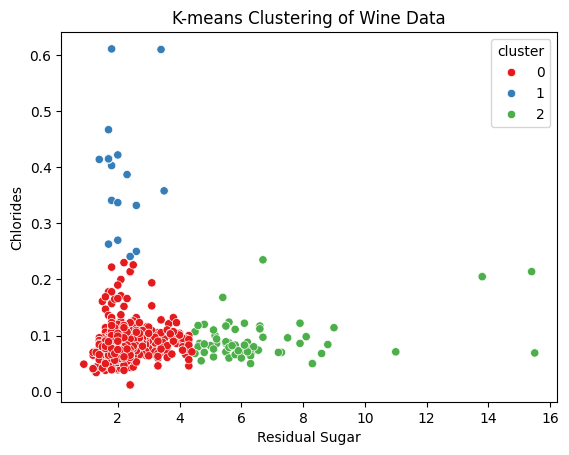

In [ ]:
plt.figure()
sns.scatterplot(x='residual sugar',y='chlorides',hue='cluster',data=df,palette='Set1')
plt.title('K-means Clustering of Wine Data')
plt.xlabel('Residual Sugar')
plt.ylabel('Chlorides')
plt.show()

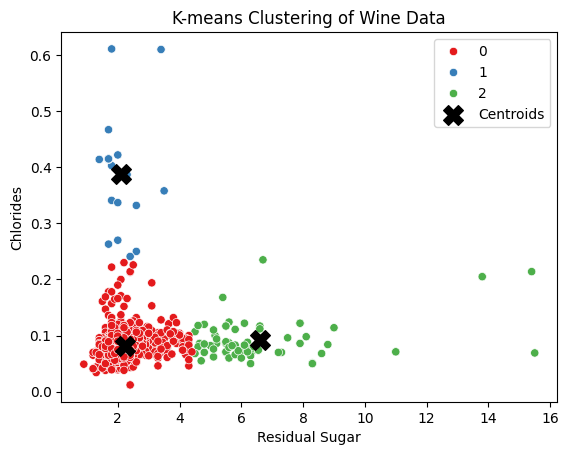

In [ ]:
sns.scatterplot(x='residual sugar',y='chlorides',hue='cluster',data=df,palette='Set1')
centroids = scaler.inverse_transform(kmeans.cluster_centers_)
plt.scatter(centroids[:,0],centroids[:,1],s=200,c='black',marker='X',label='Centroids')
plt.xlabel('Residual Sugar')
plt.ylabel('Chlorides')
plt.title('K-means Clustering of Wine Data')
plt.legend()
plt.show()